# NVIDIA Reasoning NIM

Understanding how the underlying AI model thinks, reasons, and solves complex problems.

---

## 1. What is NVIDIA Nemotron?

**NVIDIA Nemotron** is a family of state-of-the-art, open-source large language models (LLMs) designed to reason and empower enterprise AI applications. Built on the foundation of common open model architectures, the Nemotron models are fine-tuned and optimized by NVIDIA to excel at complex reasoning tasks, instruction following, and agentic workflows.

### 1.1 The Nemotron Model Family

The Nemotron family includes several specialized models:

- **Nemotron Nano v2**: An accurate and efficient hybrid Mamba-Transformer reasoning model designed for on-device and edge deployment
- **Llama 3.3 Nemotron Super 49B**: A reasoning-enhanced model optimized for complex problem-solving and multi-step reasoning in enterprise applications
- **Nemotron-Reward Models**: Models fine-tuned for evaluating and ranking responses
- **And many more!**

In this notebook, we'll be working with **`nvidia/llama-3.3-nemotron-super-49b-v1.5`**, a 49-billion parameter reasoning model that represents the cutting edge of open-source AI reasoning capabilities.

### 1.2 What Makes Nemotron Special?

- **Reasoning Capabilities**: Unlike standard LLMs that generate responses directly, Nemotron reasoning models can engage in explicit reasoning processes before providing answers.
- **Open Source**: Available under permissive licenses, enabling deployment anywhere—from cloud to on-premises infrastructure.
- **Enterprise-Ready**: Optimized for production use with NVIDIA NIM Microservices for easy deployment and scaling.
- **Agentic Workflows**: Specifically tuned to work well in agentic systems where models need to plan, reason, and execute complex tasks.

### 1.3 Understanding AI Agents

**What is an AI Agent?**

An AI agent is an autonomous system that can:
- **Perceive** its environment (receive inputs like user queries, data, or tool results)
- **Reason** about what actions to take
- **Act** on decisions (generate responses, call APIs, use tools)
- **Learn** from feedback to improve or iterate over time

Unlike simple chatbots that provide single-shot responses, agents can:
- Break down complex problems into steps and formulate an action plan
- Use external tools (calculators, databases, search engines)
- Maintain context across multiple interactions (human-in-the-loop)
- Self-reflect iteratively to build a more robust response
- Self-correct when they make mistakes

**Example Agent Workflow (with sample tool call):**
```
User Query: "Find the weather in Paris and suggest activities"
    ↓
Agent Reasoning:
  1. I need to get weather data → Use weather API tool
  2. Based on weather, suggest activities → Generate recommendations
    ↓
Agent Actions:
  1. Call weather_api("Paris")
  2. Analyze: "20°C, sunny"
  3. Suggest: "Visit outdoor cafés, walk along the Seine..."
```

### 1.4 Reasoning Tokens: The Secret to Better Agents

**What are Reasoning Tokens?**

Reasoning tokens are special tokens that allow models to "think out loud" before generating their final response. When a model uses reasoning tokens, it:

1. **Generates internal reasoning** (the "thinking" process)
2. **Arrives at a conclusion** (the actual answer)
3. **Displays the full reasoning trace** to the user or only shows the final answer depending on the user’s preference

With NVIDIA Nemotron, you can toggle reasoning on or off, providing even greater efficiency and flexibility in balancing performance and latency. 

**Why Reasoning Tokens Matter for Agents:**

| Without Reasoning Tokens | With Reasoning Tokens |
|-------------------------|----------------------|
| Model jumps to conclusions single-shot | Model thinks step-by-step |
| Higher error rates on complex problems | Better accuracy through deliberation |
| Cannot self-correct during generation | Can identify and fix mistakes mid chain-of-thought |
| Limited multi-step problem solving | Excels at dynamic planning and execution |

**Example: Counting 'r's in "strawberry"**

*Without reasoning tokens:*
```
Q: How many 'r's are in "strawberry"?
A: There are 2 'r's in "strawberry". [INCORRECT]
```

*With reasoning tokens:*
```
Q: How many 'r's are in "strawberry"?
A: [Reasoning] Let me go through each letter:
   s-t-r-a-w-b-e-r-r-y
   Position 3: 'r' (1st r)
   Position 8: 'r' (2nd r)
   Position 9: 'r' (3rd r)
   Total: 3 'r's
   [Answer] There are 3 'r's in "strawberry". [CORRECT]
```

### 1.5 Activating Reasoning Mode

**Note:** An empty system message results in reasoning mode toggled ON by default. 

The Llama 3.3 Nemotron Super 49B model can also be triggered manually to use reasoning tokens through:

1. **System Message**: Include `"/think"` or `"detailed thinking on"` in the system message
2. **Prompt Engineering**: Phrases like "Let's think step by step" or "Reason through this carefully"

When reasoning mode is active, the model will generate both:
- **Reasoning tokens** (the thinking process, often marked with special ``<think>`` / ``</think>`` tags in the output)
- **Response tokens** (the final answer for the user)

This explicit reasoning capability makes Nemotron models particularly powerful for building research agents, problem-solving assistants, and complex decision-making systems.


---

## 2. Experience NVIDIA Nemotron

Before diving into the code, let's experience the power of reasoning models firsthand!

### 🎮 2.1 Interactive Playground

Visit the NVIDIA API Catalog **[Model Card](https://build.nvidia.com/nvidia/llama-3_3-nemotron-super-49b-v1_5)** to interact with the Llama-3.3-Nemotron-Super-49B model directly in your browser.

### 📋 2.2 Try These Reasoning Challenges:

1. **Logic Puzzle**: 
   - Prompt: *"Three people are in a room: Alice, Bob, and Charlie. Alice is taller than Bob. Charlie is shorter than Bob. Who is the tallest?"*
   - Observe how the model reasons through the relationships step-by-step

2. **Math Problem**:
   - Prompt: *"If a train travels at 60 mph for 2.5 hours, then at 80 mph for 1.5 hours, what is the total distance traveled?"*
   - Watch the model break down the calculation into clear steps

3. **The Strawberry Challenge**:
   - Prompt: *"How many times does the letter 'r' appear in the word 'strawberry'?"*
   - This is a classic test where reasoning models shine compared to standard LLMs

4. **Planning Task**:
   - Prompt: *"I need to organize a team meeting for 10 people. What steps should I take? Consider scheduling, venue, agenda, and communication."*
   - See how the model structures its thinking process for complex planning

### 🔍 2.3 What to Look For:

- **Explicit Reasoning Steps**: Notice how the model shows its "thinking" process
- **Self-Correction**: Sometimes the model catches and corrects its own mistakes during reasoning
- **Structured Approach**: Observe how complex problems are broken into manageable sub-problems
- **Final Answer Clarity**: After reasoning, the model provides a clear, confident answer

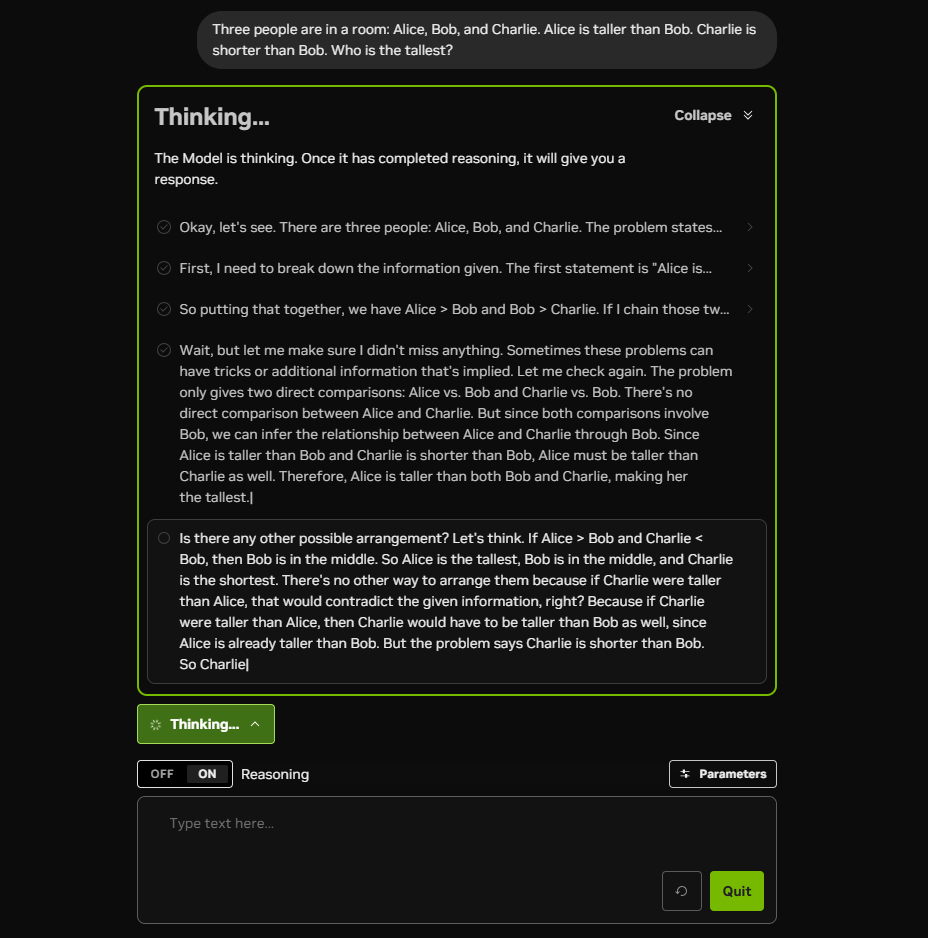

### 💡 2.4 Experiment with System Messages:

Try toggling reasoning on and off using system messages:
- **Enable reasoning**: `"/think"` or `"detailed thinking on"`
- **Disable reasoning**: `"/no_think"` or `"detailed thinking off"`

Compare the quality and accuracy of responses with and without explicit reasoning—you'll likely see better performance on complex tasks when reasoning is enabled!

While the playground is great for experimentation, real applications need programmatic access. Now that you've experienced the model's capabilities, let's learn how to integrate it into your applications in the next section.

---

## 3. Using NVIDIA-Hosted Endpoints

NVIDIA provides free, GPU-accelerated API endpoints for Nemotron models through the **NVIDIA API Catalog**. This allows you to leverage powerful reasoning capabilities without managing your own infrastructure.

### Benefits of NVIDIA-Hosted Endpoints:

✅ **No Infrastructure Required**: No need to provision GPUs or manage containers  
✅ **Fully Free To Use**: Get started with unlimited, free credits at developer-friendly rate limits  
✅ **Production-Ready**: Same enterprise-grade infrastructure that powers NVIDIA's services  
✅ **OpenAI-Compatible API**: Use all of your familiar tools and libraries (like the OpenAI SDK)  


### 3.1 Using Python

The easiest way to interact with NVIDIA's reasoning models is through the OpenAI Python SDK. Since NVIDIA's API is OpenAI-compatible, you can use the familiar `openai` library with just a few configuration changes.

#### 3.1.1 Import Required Libraries

We'll use:
- `openai`: The OpenAI Python SDK (works with NVIDIA endpoints)
- `os`: For environment variable management
- `getpass`: For secure API key input

In [ ]:
from openai import OpenAI
import os, getpass

#### 3.1.2 Set Up Your API Key

Run the cell below to securely input your NGC API key. You should have already generated these in the Prerequisites notebook. Just run the cell and paste the key. 

The code will:
1. Check if an API key is already set in your environment
2. If not, prompt you to enter it securely (your key won't be displayed in the output)
3. Validate that the key starts with `nvapi-`
4. Store it in the environment for use in subsequent cells

**Security Note**: Never hardcode API keys in your notebooks or share them publicly!


In [ ]:
if not os.environ.get("NGC_API_KEY", "").startswith("nvapi-"):
    nvapi_key = getpass.getpass("Enter your NVIDIA NGC API key: ")
    assert nvapi_key.startswith("nvapi-"), f"{nvapi_key[:5]}... is not a valid key"
    os.environ["NGC_API_KEY"] = nvapi_key
    print("✅ API key has been set in notebook environment")

#### 3.1.3 Comparing Responses: With vs Without Reasoning

To truly appreciate the power of reasoning tokens, let's compare the model's behavior with and without reasoning enabled. We'll use the classic "strawberry" challenge—a task where certain standard LLMs struggle.

**The Challenge**: Count how many times the letter 'r' appears in the word "strawberry"

We'll send the same question twice:
1. **Without reasoning**: Using the `"/no_think"` system message for a standard direct response
2. **With reasoning**: Using the `"/think"` system message

This comparison will demonstrate how reasoning tokens improve accuracy on tasks requiring careful, step-by-step analysis.

---

#### 3.1.3.1 Request WITHOUT Reasoning

Let's start by setting up our OpenAI client and making a standard request without activating reasoning mode. Notice that the system message uses ``/no_think`` explicitly to turn off reasoning, rather than ``/think`` or an empty system message (which reasons by default).

**Setting Up the Client:**
```python
client = OpenAI(
  base_url = "https://integrate.api.nvidia.com/v1",  # NVIDIA endpoint
  api_key = os.environ["NGC_API_KEY"]                # Your API key
)
```

**Creating a Standard Completion (No Reasoning):**
```python
completion_no_reasoning = client.chat.completions.create(
  model="nvidia/llama-3.3-nemotron-super-49b-v1.5",
  messages=[
    {"role":"system", "content":"/no_think"},  # Standard system message
    {"role":"user", "content":"How many 'r's are in 'strawberry'?"}
  ],
  temperature=0.6,
  top_p=0.95,
  max_tokens=1024,
  stream=True
)
```

Run the cell below to make this request:


In [ ]:
client = OpenAI(
  base_url = "https://integrate.api.nvidia.com/v1",
  api_key = os.environ["NGC_API_KEY"]
)

completion_no_reasoning = client.chat.completions.create(
  model="nvidia/llama-3.3-nemotron-super-49b-v1.5",
  messages=[
    {"role":"system","content":"/no_think"},
    {"role":"user","content":"How many 'r's are in 'strawberry'?"}
  ],
  temperature=0.6,
  top_p=0.95,
  max_tokens=1024,
  stream=True
)

**Stream and Display the Response**

Since we set `stream=True`, the model will return tokens as they're generated. This loop processes each chunk:

```python
for chunk in completion:
  if chunk.choices[0].delta.content is not None:
    print(chunk.choices[0].delta.content, end="")
```

- `chunk.choices[0]` accesses the first (and usually only) completion choice
- `.delta.content` contains the new text fragment for this chunk
- `end=""` prevents newlines, creating a smooth streaming effect

In [ ]:
print("📝 Response WITHOUT reasoning:\n")
for chunk in completion_no_reasoning:
  if chunk.choices[0].delta.content is not None:
    print(chunk.choices[0].delta.content, end="")

**What do you see?**

✅ ``nvidia/llama-3.3-nemotron-super-49b-v1.5`` is a highly capable model, so chances are the non-reasoning response you see above is actually the correct answer. 

However, not every model is as 'smart'!

**As an exercise, try switching to the predecessor model (``nvidia/llama-3.3-nemotron-super-49b-v1``) and re-running the non-reasoning query.** Did the outputs change? Are you surprised at the results you see? 

In [ ]:
print("Running predecessor (v1) model...\n")
completion_no_reasoning_v1 = client.chat.completions.create(
  model="nvidia/llama-3.3-nemotron-super-49b-v1",
  messages=[
    {"role":"system","content":"/no_think"},
    {"role":"user","content":"How many 'r's are in 'strawberry'?"}
  ],
  temperature=0.6,
  top_p=0.95,
  max_tokens=1024,
  stream=True
)

print("📝 Response WITHOUT reasoning:\n")
for chunk in completion_no_reasoning_v1:
  if chunk.choices[0].delta.content is not None:
    print(chunk.choices[0].delta.content, end="")

#### 3.1.3.2 Request WITH Reasoning Enabled

Now let's make the same request, but this time we'll activate reasoning mode using the `"/think"` system message. This tells the Nemotron model to show its step-by-step thinking process before providing the final answer.

**Why "/think" Matters:**  
The system message `"/think"` is crucial—it tells the Nemotron model to use reasoning tokens. Without it, the model would give a direct answer (which might be wrong!). With it, the model shows its step-by-step thinking process.

**Creating a Reasoning-Enabled Completion:**
```python
completion_with_reasoning = client.chat.completions.create(
  model="nvidia/llama-3.3-nemotron-super-49b-v1.5",
  messages=[
    {"role":"system", "content":"/think"},  # 🔑 Enable reasoning mode!
    {"role":"user", "content":"How many 'r's are in 'strawberry'?"}
  ],
  temperature=0.6,
  top_p=0.95,
  max_tokens=65536,  # Increased to accommodate reasoning tokens
  stream=True
)
```

**Key Parameters Explained:**

| Parameter | Value | Purpose |
|-----------|-------|---------|
| `messages[0]` | `"/think"` | **Activates reasoning mode** - tells the model to show its thinking process |
| `temperature` | `0.6` | Moderate creativity (higher = more creative, lower = more focused) |
| `top_p` | `0.95` | Considers top 95% probability tokens (nucleus sampling) |
| `max_tokens` | `65536` | Allows very long responses (important for reasoning, which can be verbose) |
| `stream` | `True` | Returns response incrementally, like ChatGPT's typing effect |

Run the cell below to make the reasoning-enabled request:


In [ ]:
completion_with_reasoning = client.chat.completions.create(
  model="nvidia/llama-3.3-nemotron-super-49b-v1.5",
  messages=[{"role":"system","content":"/think"},{"role":"user","content":"How many 'r's are in 'strawberry'?"}],
  temperature=0.6,
  top_p=0.95,
  max_tokens=65536,
  stream=True
)

**Stream and Display the Response**

Since we set `stream=True`, the model will return tokens as they're generated. This loop processes each chunk:

```python
for chunk in completion:
  if chunk.choices[0].delta.content is not None:
    print(chunk.choices[0].delta.content, end="")
```

- `chunk.choices[0]` accesses the first (and usually only) completion choice
- `.delta.content` contains the new text fragment for this chunk
- `end=""` prevents newlines, creating a smooth streaming effect

**Expected Output:**  
You should see the model's reasoning process (marked with special tag `<think>` or similar), followed by the final answer. The model will correctly count three 'r's in "strawberry" by methodically going through each letter, as well as checking its own answer for correctness!


In [ ]:
print("🧠 Response WITH reasoning:\n")
for chunk in completion_with_reasoning:
  if chunk.choices[0].delta.content is not None:
    print(chunk.choices[0].delta.content, end="")

#### 3.1.4 Key Observations: The Power of Reasoning

After running both nonreasoning and reasoning requests, you should notice several important differences:

**1. Response Quality:**
- **Without reasoning**: The model may give an incorrect answer (commonly "2" instead of "3") because it jumps to a conclusion
- **With reasoning**: The model methodically counts each letter, checks its work repeatedly, and arrives at the correct answer ("3")

**2. Transparency:**
- **Without reasoning**: You only see the final answer with no insight into how it was derived
- **With reasoning**: You can see the model's step-by-step thought process, making errors easier to identify and trust easier to build

**3. Self-Correction:**
- **Without reasoning**: If the model makes a mistake mid-response, it cannot catch it
- **With reasoning**: The model often double-checks its work and corrects errors during the thinking process

**4. Response Length:**
- **Without reasoning**: Very concise, typically just a few tokens
- **With reasoning**: Longer due to the explicit reasoning tokens, but more reliable

**Why This Matters for AI Agents:**

AI agents need to make complex decisions, often involving multiple steps and tool calls. Reasoning tokens enable agents to:
- **Plan before acting**: Think through the steps needed to accomplish a goal
- **Debug themselves**: Identify when they're about to make a mistake
- **Explain decisions**: Provide transparency for high-stakes applications
- **Handle complexity**: Break down multi-step problems systematically

The Nemotron model's reasoning capability makes it ideal for the deep research agent you'll build in this course!


## 3.2 Raw `curl` Request

For those who prefer working at the HTTP level or integrating with non-Python environments, you can use raw HTTP requests with `curl`.

**Why Use `curl`?**
- Language-agnostic (works from any environment with HTTP capabilities)
- Useful for debugging API issues
- Ideal for shell scripts or CI/CD pipelines
- Helps you understand the raw API structure

The command below makes the same request as our Python code, but directly via HTTP:

**Key Elements:**
- **Endpoint**: `https://integrate.api.nvidia.com/v1/chat/completions`
- **Headers**: 
  - `Content-Type: application/json` - We're sending JSON data
  - `Authorization: Bearer $NGC_API_KEY` - Your API key for authentication
- **Body**: JSON payload with model, messages, and parameters

Note that the output has been limited to 16 tokens for readability. You may manually set this **max_tokens** parameter to see a fuller response from the model. 

In [ ]:
!curl https://integrate.api.nvidia.com/v1/chat/completions \
-H "Content-Type: application/json" \
-H "Authorization: Bearer $NGC_API_KEY" \
-d '{"model": "nvidia/llama-3.3-nemotron-super-49b-v1.5", "messages": [{"role": "system", "content": "/think"}, {"role": "user", "content": "How many \"r\"s are in \"strawberry\"?"}], "temperature": 0.6, "top_p": 0.95, "max_tokens": 16, "stream": true}'

### 3.2.1 Understanding the Response Format

Streamed responses allow the user to see responses in real time as they are generated, which are great for use cases requiring real-time user interaction, while non-streamed (or asynchronous) responses are returned all at once in a more human readable message. Both response format types can be parsed appropriately from the model response. 

Both the Python SDK and raw `curl` requests return responses in the OpenAI Chat Completions format:

**Streamed Response** (with `"stream": true`):
```json
data: {
  "id": "chatcmpl-123",
  "object": "chat.completion.chunk",
  "created": 1234567890,
  "model": "nvidia/llama-3.3-nemotron-super-49b-v1.5",
  "choices": [{
    "index": 0,
    "delta": {
      "content": "Let"
    },
    "logprobs":null,
    "finish_reason": null
  }]
}

data: {
  "id": "chatcmpl-123",
  "object": "chat.completion.chunk",
  "created": 1234567890,
  "model": "nvidia/llama-3.3-nemotron-super-49b-v1.5",
  "choices": [{
    "index": 0,
    "delta": {
      "content": "'s"
    },
    "logprobs":null,
    "finish_reason": null
  }]

}
...
data: [DONE]
```

**Non-Streamed Response** (with `"stream": false`):
```json
{
  "id": "chatcmpl-123",
  "object": "chat.completion",
  "created": 1234567890,
  "model": "nvidia/llama-3.3-nemotron-super-49b-v1.5",
  "choices": [{
    "index": 0,
    "message": {
      "role": "assistant",
      "content": "The letter 'r' appears 3 times in the word 'strawberry'..."
    },
    "finish_reason": "stop"
  }],
  "usage": {
    "prompt_tokens": 25,
    "completion_tokens": 150,
    "total_tokens": 175
  }
}
```

**Response Fields:**
- `choices[0].message.content` or `choices[0].delta.content`: The model's text output
- `finish_reason`: Why the model stopped (`"stop"` = natural end, `"length"` = max_tokens reached)
- `usage`: Token consumption for billing and monitoring
